## __Import packages and load data__

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
# options and styles sheets
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [3]:
# mapping list for english
eng_category_names = [
    'Bread Offer',
    'Bread Rolls Offer',
    'Fine Bakery Offer',
    'Gastronomy Offer',
    'Hot Beverages Offer',
    'Pastry Offer',
    'Cake Offer',
    'Snack Offer',
    'Bread',
    'Bread Scale',
    'Bread Rolls',
    'Egg Dishes',
    'Fine Bakery',
    'Breakfasts',
    'Gastronomy Dishes',
    'Hot Beverages',
    'Cold Beverages 19%',
    'Cold Beverages 7%',
    'Pastry',
    'Cake',
    'Printen Scale',
    'Printen/Cookies',
    'Snack',
    'Snack Toppings'
]

de_category_names = [
    'Angebot Brot',
    'Angebot Brötchen',
    'Angebot Feinbäckerei',
    'Angebot Gastro',
    'Angebot Heißgetränke',
    'Angebot Konditorei',
    'Angebot Kuchen',
    'Angebot Snack',
    'Brot',
    'Brotwaage',
    'Brötchen',
    'Eigerichte',
    'Feinbäckerei',
    'Frühstücke',
    'Gastro Gerichte',
    'Heißgetränke',
    'Kaltgetränke 19%',
    'Kaltgetränke 7%',
    'Konditorei',
    'Kuchen',
    'Printen Waage',
    'Printen/Kekse',
    'Snack',
    'Snack Belag'
]

# __Sales__

In [3]:
# load data sales
sales = pd.read_parquet('../20260508_080427_sales_data.parquet', engine='pyarrow')
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 4571482 entries, 0 to 4571481
Data columns (total 7 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   category_name  str           
 2   item_id        int64         
 3   sold_quantity  float64       
 4   price          float64       
 5   revenue        float64       
 6   store_id       int64         
dtypes: datetime64[ns](1), float64(3), int64(2), str(1)
memory usage: 283.2 MB


## __Exploratory Data Analysis and Data Cleaning__

In [4]:
# eda, shape and NaN
print('Shape sales:', sales.shape)
print('\nMissing values:')
sales.isna().sum()

Shape sales: (4571482, 7)

Missing values:


date                 0
category_name        0
item_id              0
sold_quantity        0
price            96163
revenue          96163
store_id             0
dtype: int64

In [5]:
# check missing values and target = 0 (can be deleted)
print('NaN and sold_quantity == 0: ', sales[(sales.isna().any(axis=1)) & (sales.sold_quantity == 0)].shape[0])

NaN and sold_quantity == 0:  96163


In [6]:
# delete missing values
sales = sales.dropna()

print('NaN and sold_quantity == 0: ', sales[(sales.isna().any(axis=1)) & (sales.sold_quantity == 0)].shape[0])
print()
print(sales.isna().sum())

NaN and sold_quantity == 0:  0

date             0
category_name    0
item_id          0
sold_quantity    0
price            0
revenue          0
store_id         0
dtype: int64


In [7]:
# remove all sold_quantity < 0 AND price < 0 -> we don't want negative items sold or items without a price - not helpful
sales = sales[(sales.sold_quantity > 0 ) & (sales.price > 0)].reset_index(drop=True)
sales.info()


<class 'pandas.DataFrame'>
RangeIndex: 3652722 entries, 0 to 3652721
Data columns (total 7 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   category_name  str           
 2   item_id        int64         
 3   sold_quantity  float64       
 4   price          float64       
 5   revenue        float64       
 6   store_id       int64         
dtypes: datetime64[ns](1), float64(3), int64(2), str(1)
memory usage: 225.7 MB


In [8]:
# change categorical dtypes to category

sales['category_name'] = sales.category_name.astype('category')
sales['item_id']= sales.item_id.astype('category')
sales['store_id'] = sales.store_id.astype('category')

sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652722 entries, 0 to 3652721
Data columns (total 7 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   category_name  category      
 2   item_id        category      
 3   sold_quantity  float64       
 4   price          float64       
 5   revenue        float64       
 6   store_id       category      
dtypes: category(3), datetime64[ns](1), float64(3)
memory usage: 125.4 MB


In [9]:
# duplicates?
print('Duplicates:', sales.duplicated().sum())

Duplicates: 0


       sold_quantity         price       revenue
count   3.652722e+06  3.652722e+06  3.652722e+06
mean    1.806256e+01  3.082245e+00  2.655299e+01
std     6.249015e+01  2.077578e+00  3.955663e+01
min     1.500000e-02  1.000000e-02  5.000000e-02
25%     2.000000e+00  1.500000e+00  6.600000e+00
50%     5.000000e+00  2.900000e+00  1.485000e+01
75%     1.400000e+01  3.990000e+00  3.120000e+01
max     8.620000e+03  1.250000e+02  3.522659e+03


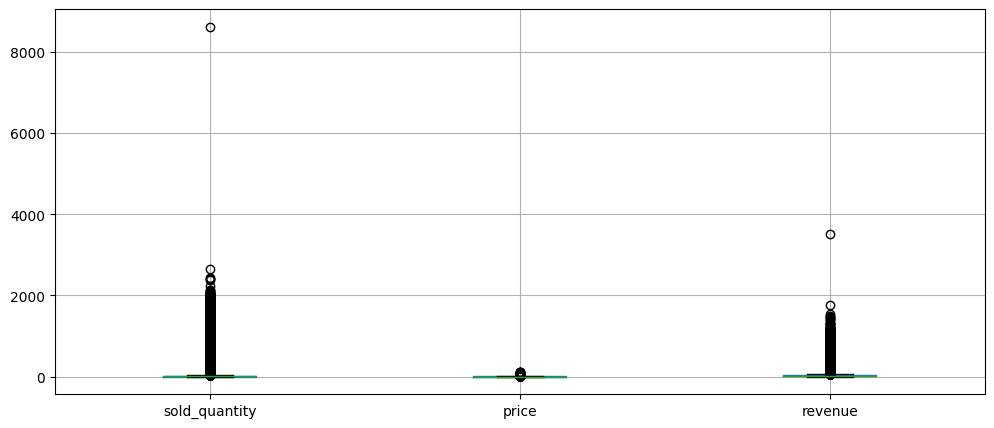

--- Outliers ---
Max value vs Median:
sold_quantity Max: 8620.0
sold_quantity Median: 5.0
revenue Max: 3522.658999999999
revenue Median: 14.850000000000001


In [10]:
# EDA, Outliers
print(sales.describe(include='number'))
plt.style.use('default')
sales.boxplot(figsize=(12,5))
plt.show()
print('--- Outliers ---')
print('Max value vs Median:')
print('sold_quantity Max:', sales.sold_quantity.max())
print('sold_quantity Median:', sales.sold_quantity.median())
print('revenue Max:', sales.revenue.max())
print('revenue Median:', sales.revenue.median())


In [11]:
# remove outlier target
max_val = sales.sold_quantity.max()
sales = sales[sales.sold_quantity < max_val]


In [12]:
# remove outlier revenue
max_rev = sales.revenue.max()
sales = sales[sales.revenue < max_rev]


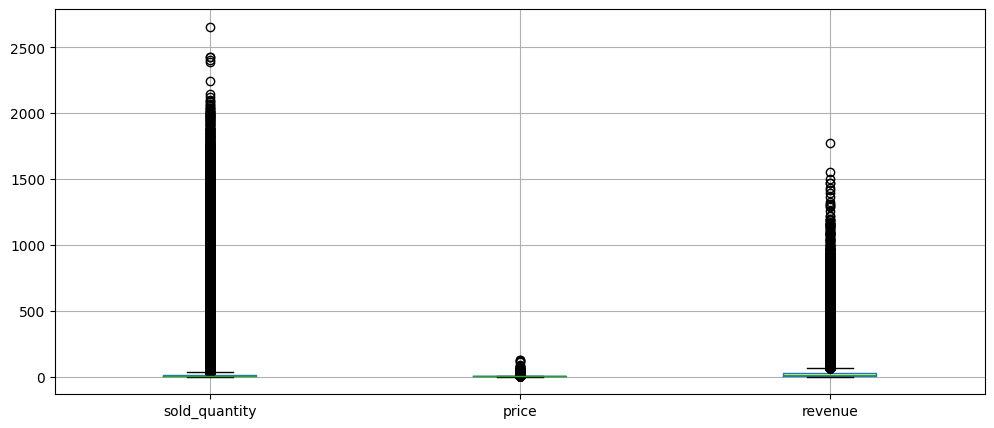

In [13]:
# boxplot after removing outliers
sales.boxplot(figsize=(12,5))
plt.show()

##  __Development Target over Time__

- curve year - check
- best weekday
- 10 ten stores

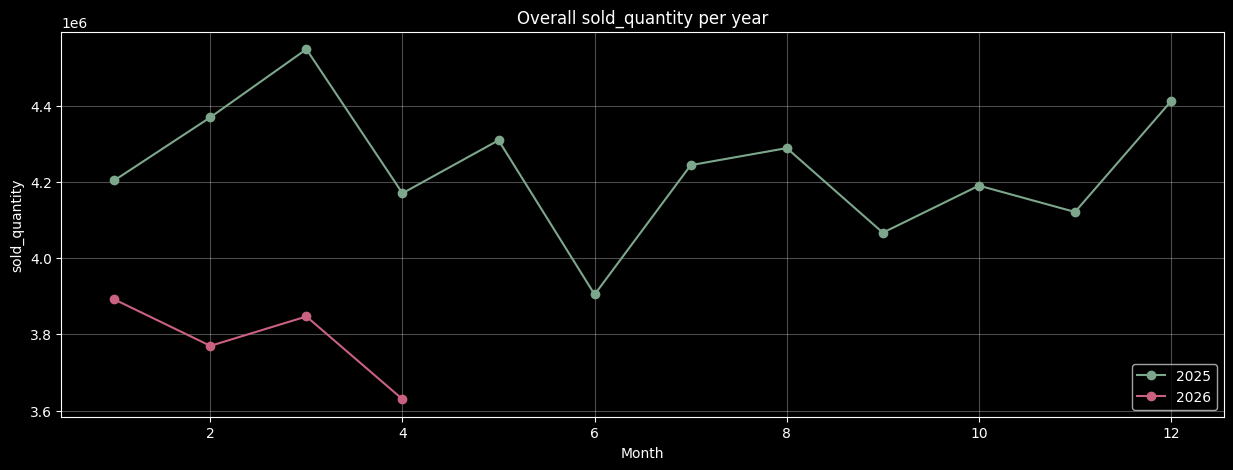

In [14]:
# curve
# separatin years
sales_2025 = sales[sales.date.dt.year == 2025]
sales_2026 = sales[sales.date.dt.year == 2026]

# split into months
month_25 = sales_2025.date.dt.month#.astype('str')
month_26= sales_2026.date.dt.month#.astype('str')

# calculating sum for target
group_period = sales_2025.groupby(month_25)['sold_quantity'].sum()
group_period_26 = sales_2026.groupby(month_26)['sold_quantity'].sum()
#display(group_period, group_period_26)


plt.style.use('dark_background')

# plot
plt.figure(figsize=(15,5))
plt.plot(group_period, '-o', label='2025', color='#7DA78C' )
plt.plot(group_period_26, '-o', label='2026', color='#CA6180')

plt.title('Overall sold_quantity per year')
plt.xlabel('Month')
plt.ylabel('sold_quantity')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()



In [15]:
# calculate top 10 stores by revenue 
best_store = sales_2025.groupby('store_id')['revenue'].sum().sort_values(ascending=True).tail(10)

# calculate target aggregations for best weekday
wd = sales_2025.date.dt.weekday
best_wd = sales_2025.groupby(wd)['sold_quantity'].agg(['count', 'sum', 'mean', 'median'])

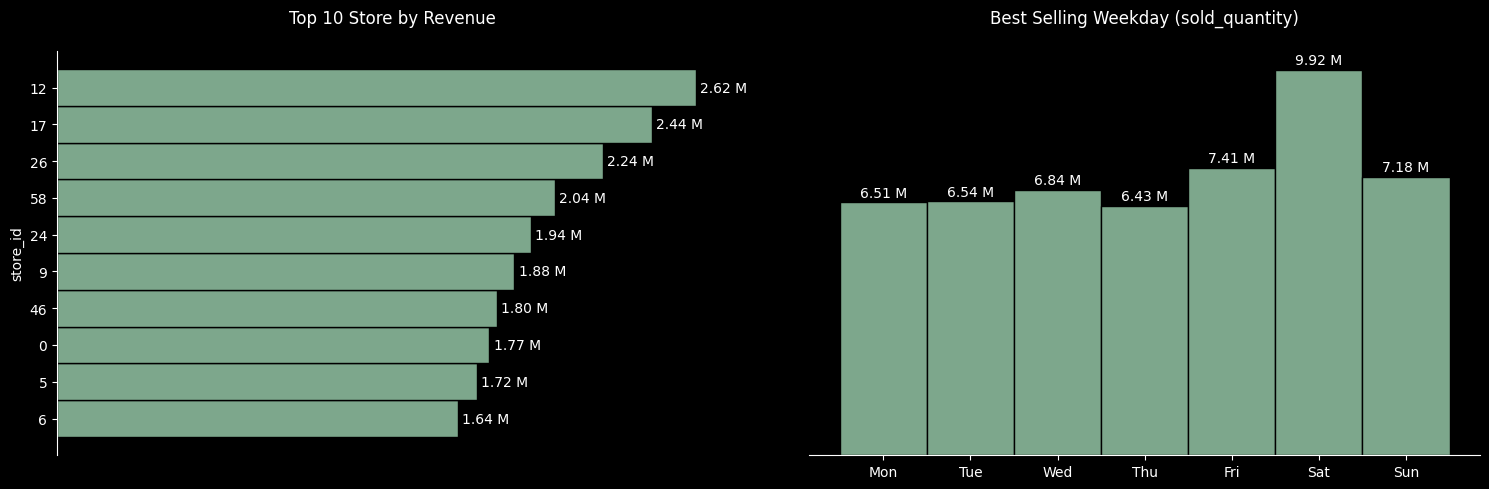

In [16]:
# create figure
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot best store
bars_stores = ax[0].barh(best_store.index.astype(str), best_store.values, height=1, edgecolor='k', label='Revenue', color='#7DA78C' )

# show values at the end of the horizontal bars
labels_h = [f'{v/1e6:.2f} M' for v in best_store.values]
ax[0].bar_label(bars_stores, labels_h, padding=3)

# remove ugly axes
ax[0].spines[['top', 'right', 'bottom']].set_visible(False)
ax[0].set_xticks([])

ax[0].set_ylabel('store_id')
ax[0].set_title('Top 10 Store by Revenue', pad=20)


# ---------------------------------------------------------------

# plot best weekday
bars_wd = ax[1].bar(best_wd.index, best_wd['sum'], width=1, edgecolor='k', label='Sold Qty.', color='#7DA78C')

# labels for on top of bars
labels = [f'{val/1000000:.2f} M' for val in best_wd['sum']]
ax[1].bar_label(bars_wd, labels, padding=2)

# adding weeday names for readabilty
ax[1].set_xticks(best_wd.index, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# remove unneccassary axes
ax[1].spines[['top', 'right', 'left']].set_visible(False)
ax[1].set_yticks([])

ax[1].set_title('Best Selling Weekday (sold_quantity)', pad=20)

plt.tight_layout(w_pad=4)
plt.show()

## __Investigating items within their categories__

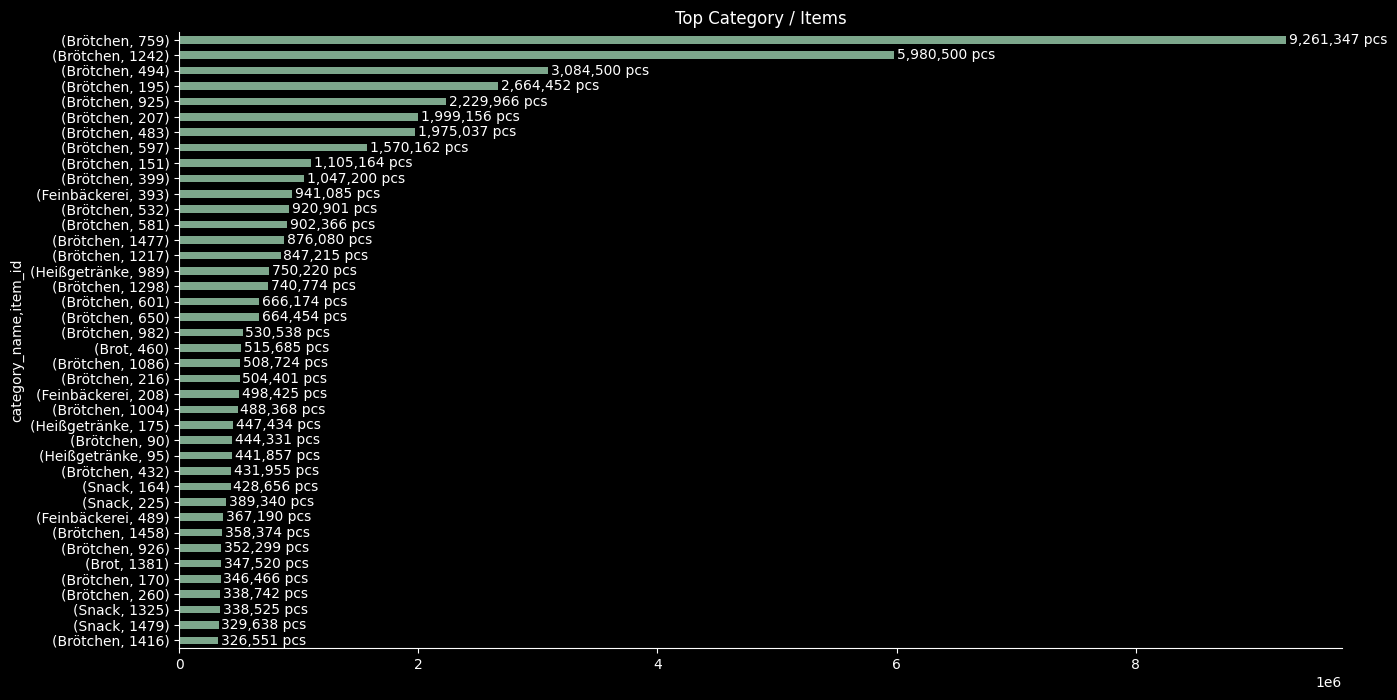


Observation:
We can see that the category named Brötchen dominates the actual distribution.
Also, we see that item id 759 is by far the best selling product, followed by item id 1242. 
Lets dive a bit deeper to get a clearer view.



In [17]:
# first view, distribution of target

n = 40

# top n items sold ->  visualized
bars = sales.groupby(['category_name', 'item_id'])['sold_quantity'].sum()\
.sort_values(ascending=True)\
.tail(n)\
.plot.barh(figsize=(15,8), color='#7DA78C', title='Top Category / Items')

for c in bars.containers:
    labels = [f'{v:,.0f} pcs' for v in c.datavalues]
    plt.bar_label(container=c, labels=labels, padding=2)

plt.gca().spines[['top','right']].set_visible(False)
plt.show()

print('''
Observation:
We can see that the category named Brötchen dominates the actual distribution.
Also, we see that item id 759 is by far the best selling product, followed by item id 1242. 
Lets dive a bit deeper to get a clearer view.
''')

In [18]:
# Let's first look at the categorie_names and their corresponding item_ids

# count unique category_names
print('Count of category_names:', sales.category_name.nunique())

# list all unique category_names
cat_list = sorted(sales.category_name.unique().tolist())
print(cat_list)

## ------------------------------------------

# count of unique item_ids overall
print('-'*70)
print('\nCount of unique item_ids:', sales.item_id.nunique())
print()

# number of unique item_ids per category_name
print('Count of unique item_ids per category_name:\n')
items_per_category_name = sales.groupby(['category_name'])['item_id'].nunique().sort_values(ascending=False).reset_index()
print(items_per_category_name)

print()
print('🧐💬 We will look at the first 30 top items for the first 10 categories holding the most items.and as well at all items of the the other categories.')

Count of category_names: 24
['Angebot Brot', 'Angebot Brötchen ', 'Angebot Feinbäckerei', 'Angebot Gastro', 'Angebot Heißgetränke', 'Angebot Konditorei', 'Angebot Kuchen', 'Angebot Snack', 'Brot', 'Brotwaage', 'Brötchen', 'Eigerichte', 'Feinbäckerei', 'Frühstücke', 'Gastro Gerichte', 'Heißgetränke', 'Kaltgetränke 19%', 'Kaltgetränke 7%', 'Konditorei', 'Kuchen', 'Printen Waage', 'Printen/Kekse', 'Snack', 'Snack Belag']
----------------------------------------------------------------------

Count of unique item_ids: 1197

Count of unique item_ids per category_name:

           category_name  item_id
0               Brötchen      180
1                   Brot      164
2                  Snack      157
3             Konditorei      147
4                 Kuchen      108
5           Feinbäckerei       87
6          Printen/Kekse       70
7       Kaltgetränke 19%       52
8           Heißgetränke       50
9           Angebot Brot       34
10         Angebot Snack       30
11           Snack Be

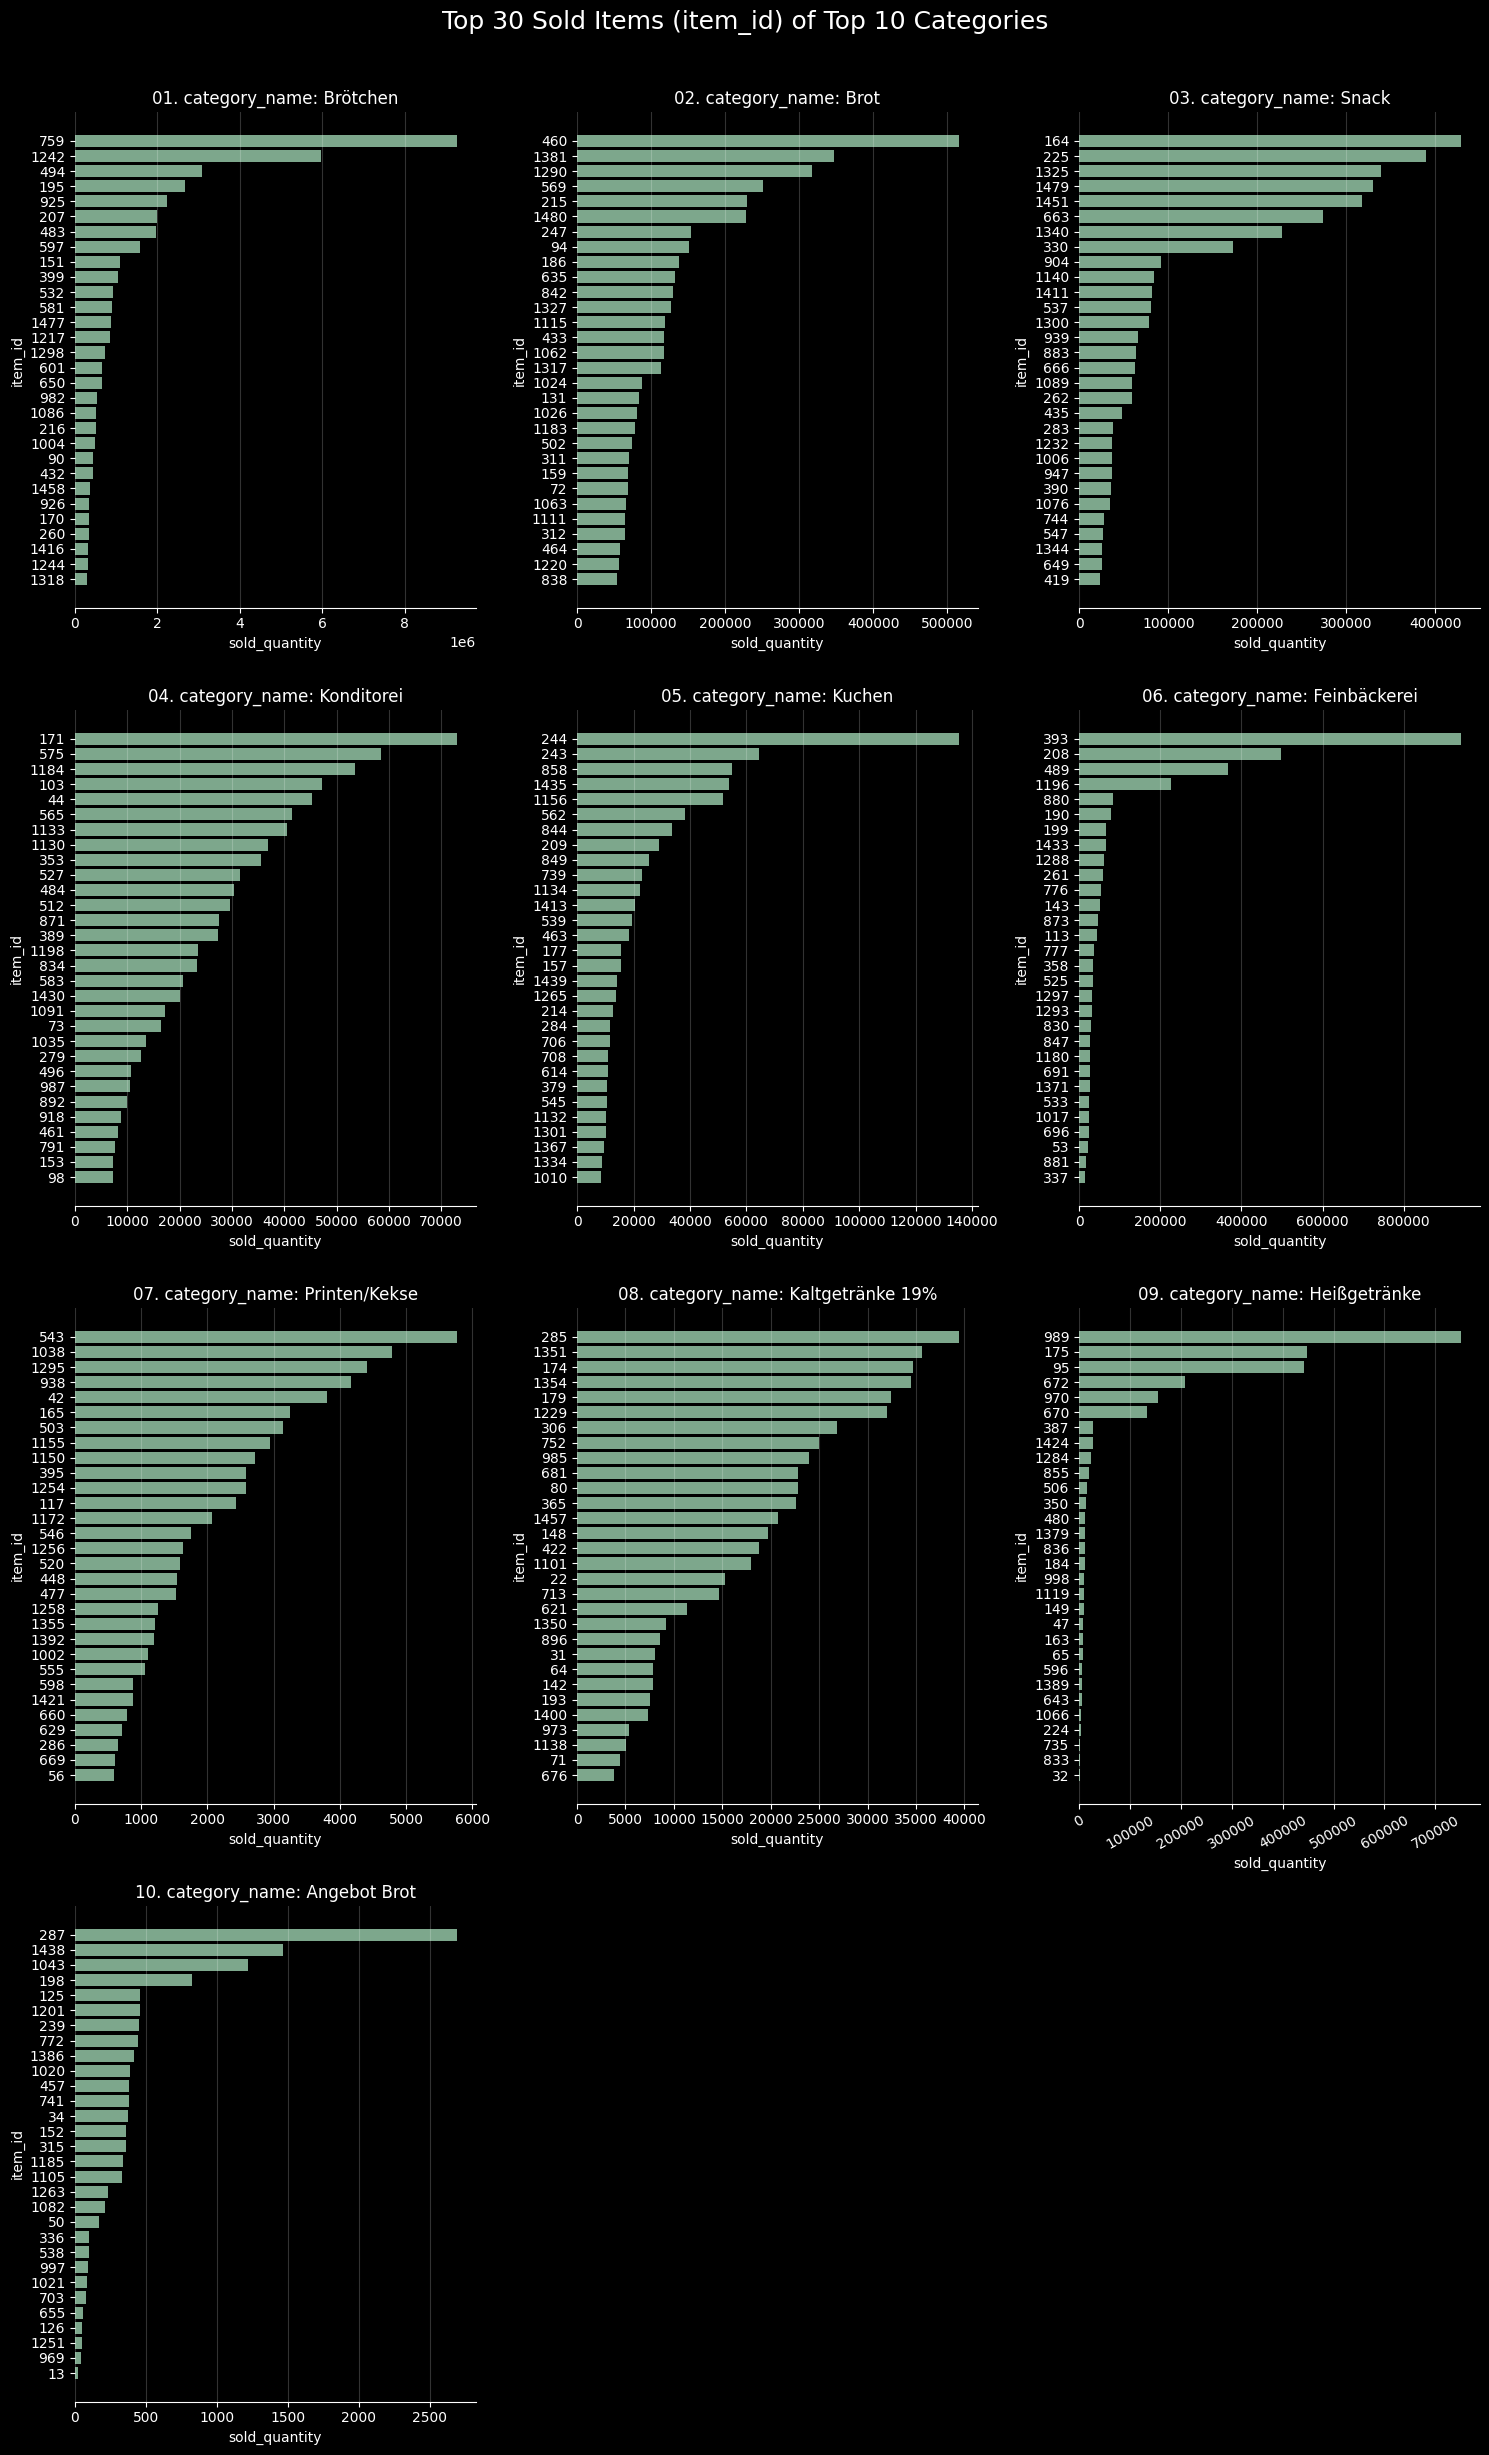

In [19]:
# split items_per_cat list
top_10_category_names = items_per_category_name.category_name[:10]
last_14_category_names = items_per_category_name.category_name[10:]

# top n items
n = 30

fig, axs = plt.subplots(4, 3, figsize=(15, 25))
ax = axs.flatten()

# top n items of top 10 category_names
for i, cat in enumerate(top_10_category_names):
    # top n item_ids of category_name
    sales_cat = sales[sales.category_name == cat].groupby(['item_id'])['sold_quantity'].sum().sort_values(ascending=True).tail(n)
    #print(cat)
    #display(sales_cat.sort_values(ascending=False))
    #print('-'*70)
    ax[i].barh(sales_cat.index.astype(str), sales_cat.values, color='#7DA78C' )
    
    ax[i].set_title(f'{i+1:02}. category_name: {cat}')
    ax[i].set_ylabel('item_id')
    ax[i].set_xlabel('sold_quantity')
    ax[i].spines[['top', 'left', 'right']].set_visible(False)
    ax[i].grid(axis='x', alpha=0.2)
    if cat == "Heißgetränke":
        ax[i].tick_params(axis='x', rotation=30)
    

fig.suptitle(f'Top {n} Sold Items (item_id) of Top 10 Categories', fontsize=18)

# remove empty graphs at the end
for blank in range(len(top_10_category_names), len(ax)):
    fig.delaxes(ax[blank])
    
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5) 
plt.show()



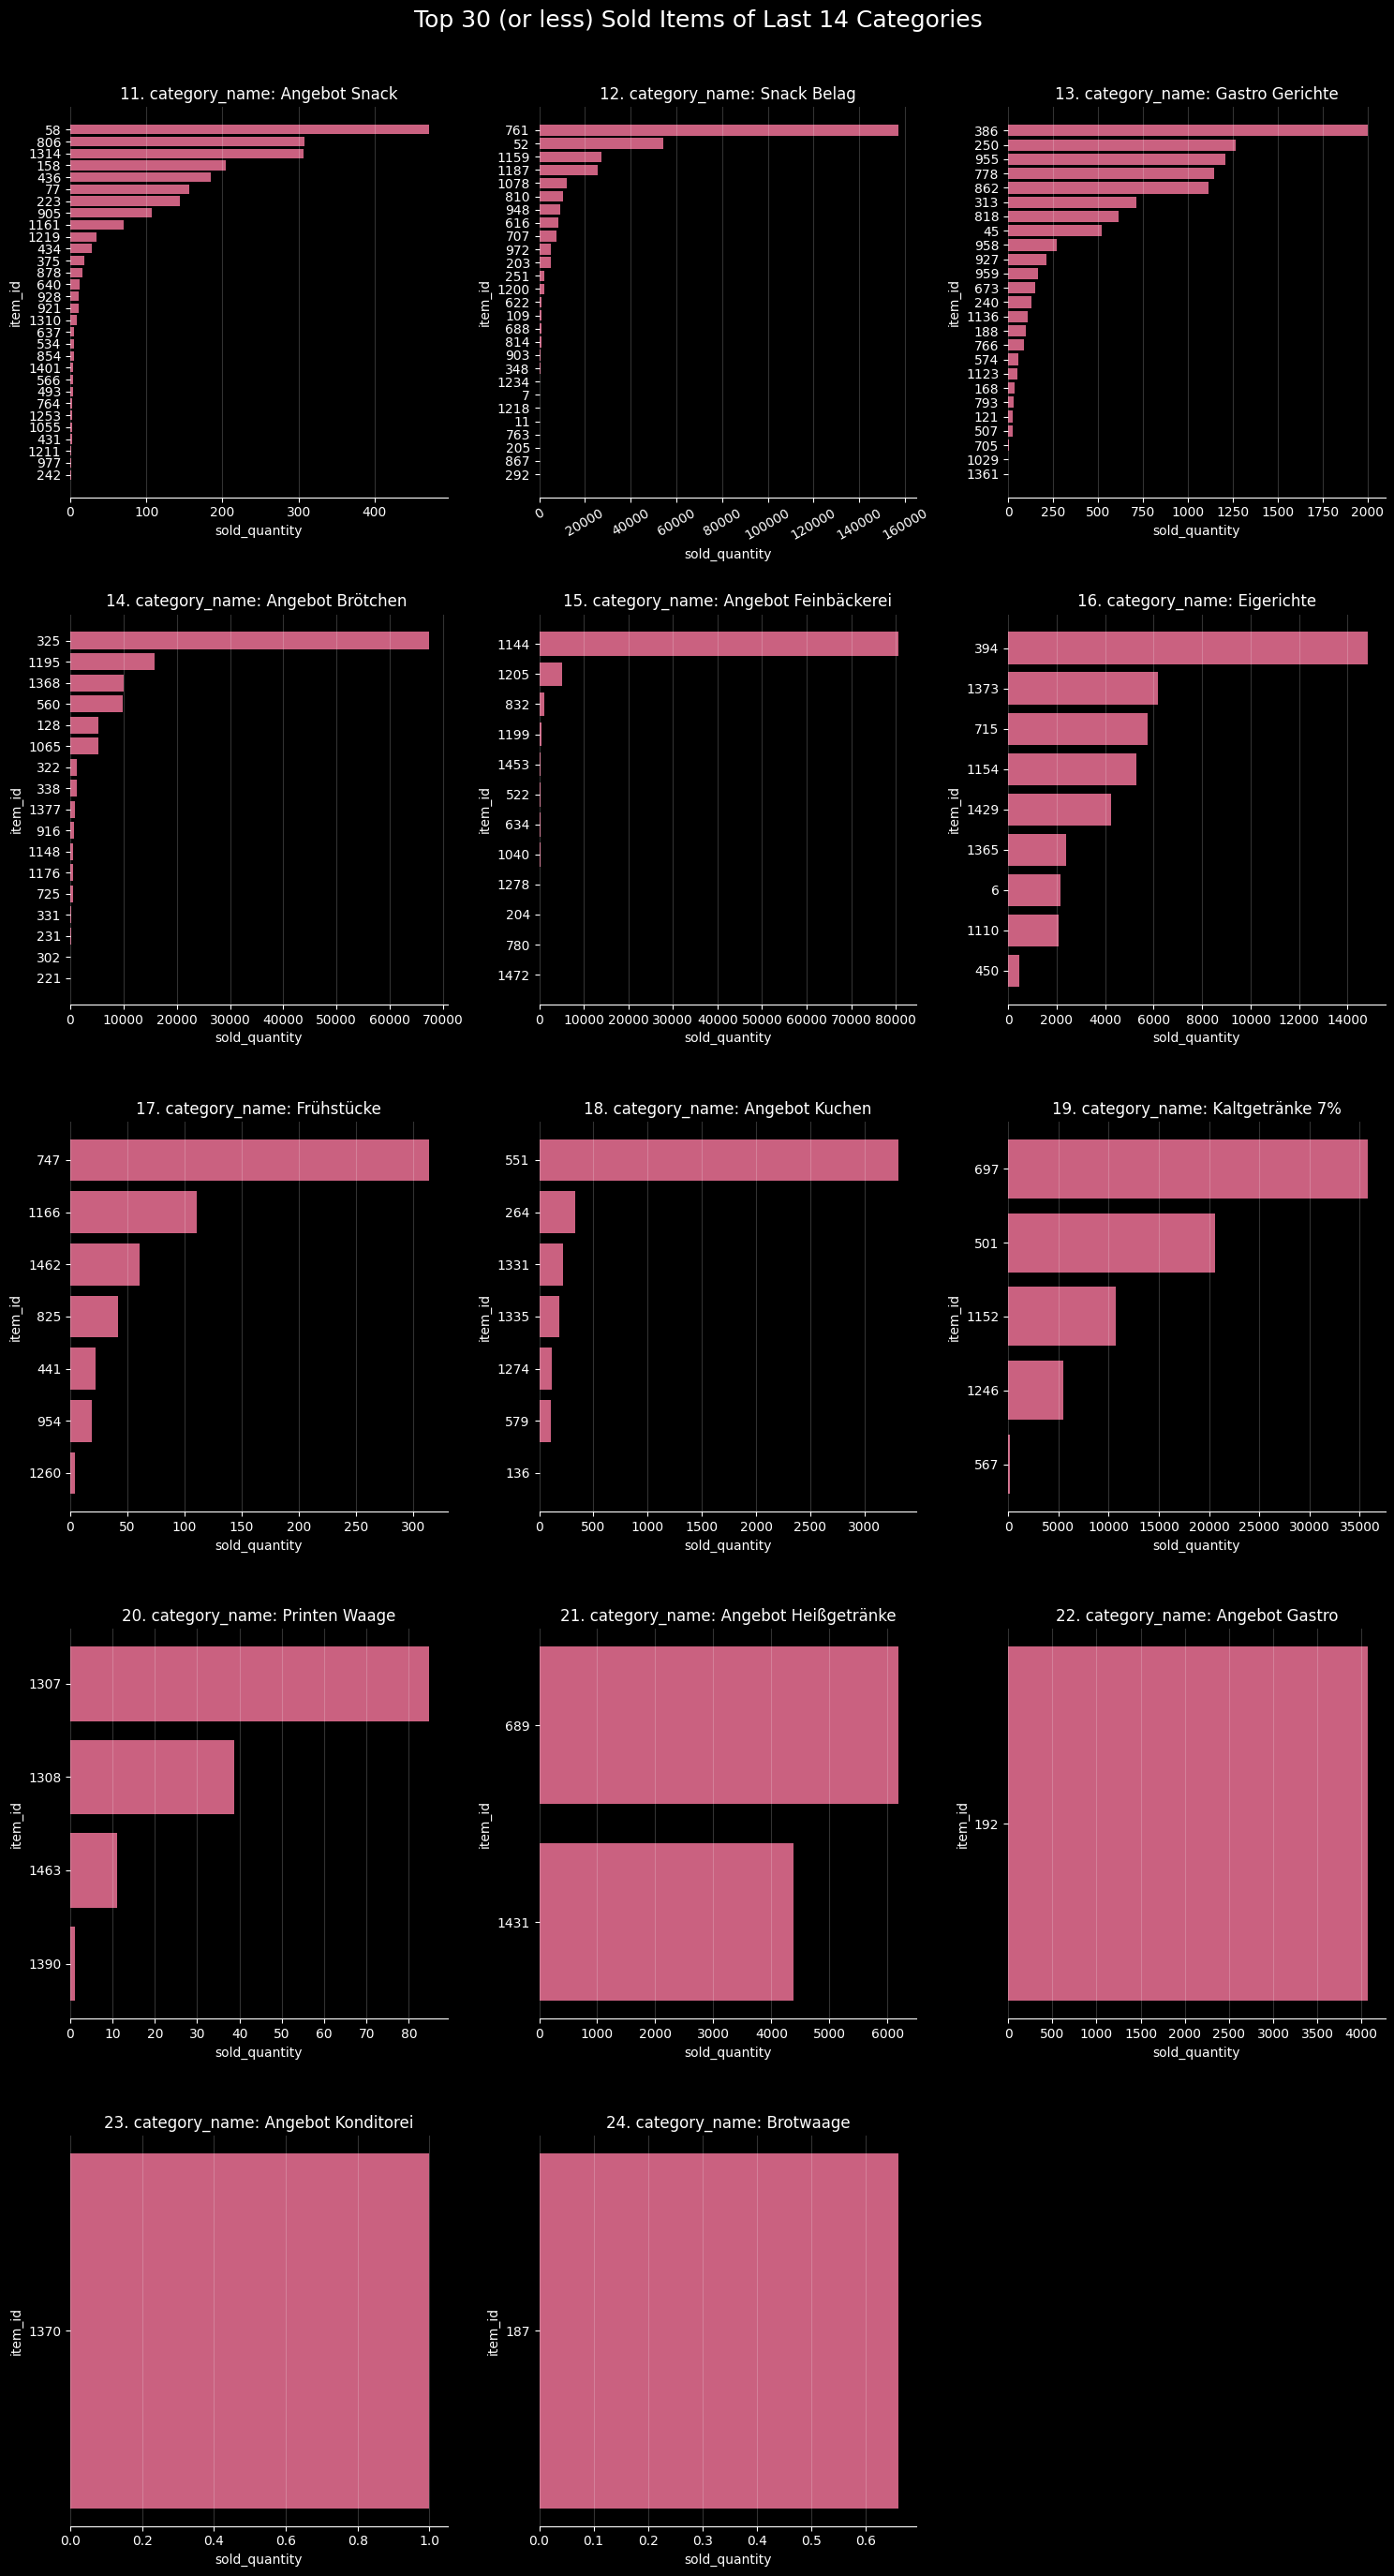

In [20]:
# last 14 cats
fig, axs = plt.subplots(5, 3, figsize=(15, 28))
ax = axs.flatten()
n = n  # see cell above

# top n items of last 14 category_names
for i, cat in enumerate(last_14_category_names):
    # top n item_ids of category_name
    sales_cat = sales[sales.category_name == cat].groupby(['item_id'])['sold_quantity'].sum().sort_values(ascending=True).tail(n)
    #print(cat)
    #display(sales_cat.sort_values(ascending=False))
    #print('-'*70)
    ax[i].barh(sales_cat.index.astype(str), sales_cat.values, color='#CA6180')
    
    ax[i].set_title(f'{i+11:02}. category_name: {cat}')
    ax[i].set_ylabel('item_id')
    ax[i].set_xlabel('sold_quantity')
    ax[i].spines[['top', 'left', 'right']].set_visible(False)
    ax[i].grid(axis='x', alpha=0.2)
    if cat == "Snack Belag":
        ax[i].tick_params(axis='x', rotation=30)
    

fig.suptitle(f'Top {n} (or less) Sold Items of Last 14 Categories', fontsize=18)

# remove not used graphs
for blank in range(len(last_14_category_names), len(ax)):
    fig.delaxes(ax[blank])
    
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5) 
plt.show()

## __Create consecutive Time Range__

In [21]:
# create a sales_all_dates consecutive time range fot later feature creation (lags, Rollings) and for making sure
# that all holiday dates in the holidays table find its referring sale dates  

### creating new multiindex to get every date for every store_id item_id combination

# sort, aggregate 
sales_agg = sales.sort_values('date')

# date range from sale data min and max
date_range = pd.date_range(sales_agg.date.min(), sales_agg.date.max(), freq='D')
all_stores = sales_agg.store_id.unique()
all_items  = sales_agg.item_id.unique()

# new multi index store x item x date
all_dates_index = pd.MultiIndex.from_product([all_stores, all_items, date_range], names=['store_id', 'item_id', 'date'])

# new dataframe with consecutive time range and lots of NaNs
sales_all_dates = sales_agg.set_index(['store_id', 'item_id', 'date']).reindex(all_dates_index).reset_index()

## __Fixing variable category_names__

In [22]:
# check new dataframe

# compare rows
print('Rows sales:', sales.shape[0])
print('Rows sales_all_dates:', sales_all_dates.shape[0])
print()

# missing values
print('Rows sales_all_dates not NaN:')
print(sales_all_dates.isna().sum())

# re-establish category_names which is "destoyed" after reindexing

# lookup table for category_names -> item_id
mapping = sales_agg[['item_id', 'category_name']].drop_duplicates('item_id').sort_values('item_id').set_index('item_id')['category_name']
sales_all_dates['category_name'] = sales_all_dates["item_id"].map(mapping)

# check again after mapping
print('--'*60)
print('After mapping:\n')
print('Rows sales:', sales.shape[0])
print('Rows sales_all_dates:', sales_all_dates.shape[0])
print()

# missing values
print('Rows sales_all_dates not NaN:')
print(sales_all_dates.isna().sum())
print()
print('Variable category_names now has no more missing values.')

Rows sales: 3652720
Rows sales_all_dates: 35413245

Rows sales_all_dates not NaN:
store_id                0
item_id                 0
date                    0
category_name    31760525
sold_quantity    31760525
price            31760525
revenue          31760525
dtype: int64
------------------------------------------------------------------------------------------------------------------------
After mapping:

Rows sales: 3652720
Rows sales_all_dates: 35413245

Rows sales_all_dates not NaN:
store_id                0
item_id                 0
date                    0
category_name           0
sold_quantity    31760525
price            31760525
revenue          31760525
dtype: int64

Variable category_names now has no more missing values.


# __Stores__

In [23]:
# load data

stores = pd.read_parquet('../20260508_080427_stores.parquet', engine='fastparquet')
stores.head()


,subdivision_code,country_code,zipcode,store_id
0,DE-NW,DE,52062,0
1,DE-NW,DE,52224,1
2,DE-NW,DE,52134,2
3,DE-NW,DE,52062,3
4,DE-NW,DE,52222,4


## __EDA and Cleaning__

In [24]:
# missing values?
print('Missing values:')
print(stores.isna().sum())
print()

# duplicates?
print('Duplicates:', stores.duplicated().sum())
print()

# unique values
print('Unique column values:')
cols_to_del = []
for col in stores.columns:
    count = stores[col].nunique()
    cols_to_del.append(col) if count == 1 else None
    status = "(column deleted)" if count == 1 else ""
    print(f'{col}: {count} {status}')

# removing columns with only 1 constant value
if len(cols_to_del) > 0:
    stores = stores.drop(columns=cols_to_del, errors='ignore')

stores.head()

Missing values:
subdivision_code    0
country_code        0
zipcode             0
store_id            0
dtype: int64

Duplicates: 0

Unique column values:
subdivision_code: 1 (column deleted)
country_code: 1 (column deleted)
zipcode: 35 
store_id: 84 


,zipcode,store_id
0,52062,0
1,52224,1
2,52134,2
3,52062,3
4,52222,4


## __Merging sales and stores dataframes__

In [25]:
# merging two of four dfs
sales_stores = sales_all_dates.merge(right=stores, how='left', on='store_id')

In [26]:
# check for new duplicates and missing values
print('Duplicates after merging:', sales_stores.duplicated(subset=['store_id', 'item_id', 'date']).sum())
print()

print('Missing values after merging:')
print(sales_stores.isna().sum())

Duplicates after merging: 0

Missing values after merging:
store_id                0
item_id                 0
date                    0
category_name           0
sold_quantity    31760525
price            31760525
revenue          31760525
zipcode                 0
dtype: int64


# __Holidays__

In [27]:
# load data
holidays = pd.read_parquet('../20260508_080427_holidays.parquet', engine='fastparquet')
holidays.head()

,zipcode,subdivision_code,date,holiday_name,holiday_type
0,41812,DE-NW,2025-01-01,Neujahr,holiday
1,41812,DE-NW,2025-01-01,Weihnachtsferien,school_holiday
2,41812,DE-NW,2025-01-02,Weihnachtsferien,school_holiday
3,41812,DE-NW,2025-01-03,Weihnachtsferien,school_holiday
4,41812,DE-NW,2025-01-04,Weihnachtsferien,school_holiday


## __EDA and Cleaning__

In [28]:
# EDA and Cleaning
print('Info:')
print(holidays.info())
print()

# describe it
print('Description:')
display(holidays.describe(include='object'))
print()

# missing values?
print('Missing values:')
print(holidays.isna().sum())
print()

# duplicates?
print('Duplicates:', holidays.duplicated().sum())
print()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 6531 entries, 0 to 6530
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           6531 non-null   object        
 1   subdivision_code  6531 non-null   object        
 2   date              6531 non-null   datetime64[ns]
 3   holiday_name      6531 non-null   object        
 4   holiday_type      6531 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 255.2+ KB
None

Description:


,zipcode,subdivision_code,holiday_name,holiday_type
count,6531,6531,6531,6531
unique,36,2,47,3
top,52531,DE-NW,Sommerferien,school_holiday
freq,371,6336,1702,4236



Missing values:
zipcode             0
subdivision_code    0
date                0
holiday_name        0
holiday_type        0
dtype: int64

Duplicates: 0



## __Investigating variable subdivision_code__

In [29]:
# a subdivision_code is likly wrong
print('Unique values of variable subdivision_code:', holidays.subdivision_code.nunique())
print(holidays.subdivision_code.unique())

# should only be one subdivision_code since the project is limited to one federal state of Germany (DE_NW)
correct_zipcode = holidays[holidays.subdivision_code == "DE-BB"].groupby(['subdivision_code'])['zipcode'].unique().values[0][0]
wrong_subdivision_code = holidays[holidays.subdivision_code == "DE-BB"].groupby(['subdivision_code'])['zipcode'].unique().index[0]

print('''
Observation: 
Since the project is limited to only one ferderal country of germany (north-rhine westphalia -> "DE_NW") and the associated zipcode "{}"
with the wrong subdivision_code "{}" is in fact located in the northhine-westphalia area this obviously is a mistake and we could delete the wrong subdivision_code
from the dataframe.

BUT: After deleting the wrong zipcode, this variable only contains one constant value, therefor we remove the whole variable at all.
'''.format(correct_zipcode, wrong_subdivision_code))

# remove variable subdivision_code
holidays = holidays.drop(columns=['subdivision_code'], errors='ignore')

holidays.head()

Unique values of variable subdivision_code: 2
['DE-NW' 'DE-BB']

Observation: 
Since the project is limited to only one ferderal country of germany (north-rhine westphalia -> "DE_NW") and the associated zipcode "52531"
with the wrong subdivision_code "DE-BB" is in fact located in the northhine-westphalia area this obviously is a mistake and we could delete the wrong subdivision_code
from the dataframe.

BUT: After deleting the wrong zipcode, this variable only contains one constant value, therefor we remove the whole variable at all.



,zipcode,date,holiday_name,holiday_type
0,41812,2025-01-01,Neujahr,holiday
1,41812,2025-01-01,Weihnachtsferien,school_holiday
2,41812,2025-01-02,Weihnachtsferien,school_holiday
3,41812,2025-01-03,Weihnachtsferien,school_holiday
4,41812,2025-01-04,Weihnachtsferien,school_holiday


In [30]:
## checking again for duplicates
#print('Rows holidays', holidays.shape[0])
#dupes = holidays.duplicated()
#print('Duplicates after removing subdivision_code:', dupes.sum())#

## dropping dupes
#holidays = holidays.drop_duplicates()
#print()#

## checking again
#dupes = holidays.duplicated()
#print('Duplicates after droppung missing values:', dupes.sum())

In [31]:
# some dates have two holiday names. we keep only the first
holidays = holidays.drop_duplicates(subset=['zipcode', 'date'], keep='first')

holidays.head()

,zipcode,date,holiday_name,holiday_type
0,41812,2025-01-01,Neujahr,holiday
2,41812,2025-01-02,Weihnachtsferien,school_holiday
3,41812,2025-01-03,Weihnachtsferien,school_holiday
4,41812,2025-01-04,Weihnachtsferien,school_holiday
5,41812,2025-01-05,Weihnachtsferien,school_holiday


## __Merging sales_stores with holidays__

In [32]:
# before merging

# checking if all holiday date are in our sales data
print('Sales_stores date count:', sales_stores.date.nunique())
print('Holidays date count:', holidays.date.nunique())

# getting unique dates
sales_dates = sales_stores.date.unique()
holidays_dates = holidays.date.unique()

# checking which holiday dates are not present in the sales data
not_in_sales = [str(d)[:10] for d in holidays_dates if d not in sales_dates]
print('Holidays dates not in sales data: ', not_in_sales)


Sales_stores date count: 485
Holidays date count: 193
Holidays dates not in sales data:  []


In [33]:
# merging holidays into sales_store dataframe
sales_stores_holidays = sales_stores.merge(holidays, on=['zipcode', 'date'], how='left')

In [34]:
# check for new duplicates and missing values after merging
print('Duplicates after merging:', sales_stores_holidays.duplicated(subset=['store_id', 'item_id', 'date']).sum())
print()

# counting missing values
no_holidays = sales_stores_holidays.isna().sum()
print('Missing values after merging:')
print(no_holidays)
print()

# observation
print(f'''
Observation:
There are {no_holidays[-1:].values[0]:,} missing values in holiday_name and holiday_type. 
These NaN are literally not a holiday, so we fill them with the string value "no_holiday".
''')

Duplicates after merging: 0

Missing values after merging:
store_id                0
item_id                 0
date                    0
category_name           0
sold_quantity    31760525
price            31760525
revenue          31760525
zipcode                 0
holiday_name     24004638
holiday_type     24004638
dtype: int64


Observation:
There are 24,004,638 missing values in holiday_name and holiday_type. 
These NaN are literally not a holiday, so we fill them with the string value "no_holiday".



In [35]:
# fill NaN in holidays
sales_stores_holidays[['holiday_name', 'holiday_type']] = sales_stores_holidays[['holiday_name', 'holiday_type']].fillna('no_holiday')

In [36]:
print('Missing values:')
print(sales_stores_holidays.isna().sum())
print()
print('''
The missing values left at this time are expected and we will deal with them later after the feature creation part.
''')

Missing values:
store_id                0
item_id                 0
date                    0
category_name           0
sold_quantity    31760525
price            31760525
revenue          31760525
zipcode                 0
holiday_name            0
holiday_type            0
dtype: int64


The missing values left at this time are expected and we will deal with them later after the feature creation part.



# __Weather__

In [37]:
# load weather data
weather = pd.read_parquet('../20260508_080427_weather.parquet', engine='fastparquet')


# see all cols
pd.set_option('display.max_columns', None)
weather.head()

,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
0,2025-01-01,14:00,41812,8.0,39.0,226.0,SW,122,Overcast,0.0,61.0,10.0,1012.0,96.0,8.0,1.0,3.0,60.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,2025-01-01,00:00,41812,6.0,34.0,229.0,SW,113,Clear,0.0,78.0,10.0,1021.0,7.0,6.0,2.0,1.0,57.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-01-01,01:00,41812,6.0,35.0,230.0,SW,113,Clear,0.0,79.0,10.0,1021.0,13.0,6.0,2.0,1.0,57.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-01-01,02:00,41812,6.0,36.0,230.0,SW,113,Clear,0.0,79.0,10.0,1020.0,12.0,6.0,2.0,1.0,59.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2025-01-01,03:00,41812,6.0,37.0,231.0,SW,116,Partly cloudy,0.0,77.0,10.0,1019.0,33.0,6.0,2.0,1.0,60.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## __EDA and Cleaning__

In [38]:
# EDA and Cleaning
print('Dubplicates:', weather.duplicated().sum())
print()
print('Info:')
print(weather.info())

Dubplicates: 0

Info:
<class 'pandas.DataFrame'>
RangeIndex: 419040 entries, 0 to 419039
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 419040 non-null  datetime64[ns]
 1   time                 419040 non-null  object        
 2   zipcode              419040 non-null  object        
 3   temperature          419040 non-null  float64       
 4   wind_speed           419040 non-null  float64       
 5   wind_degree          419040 non-null  float64       
 6   wind_dir             419040 non-null  object        
 7   weather_code         419040 non-null  int64         
 8   weather_description  419040 non-null  object        
 9   precip               419040 non-null  float64       
 10  humidity             419040 non-null  float64       
 11  visibility           419040 non-null  float64       
 12  pressure             419040 non-null  float64       
 13  clo

In [39]:
# separate columns to numerical and categorical

# first turning variable weather_code into object since it works as a category
weather['weather_code'] = weather.weather_code.astype('object')

# separate cols
num_cols = weather.select_dtypes(include='number').columns
cat_cols = weather.select_dtypes(exclude='number').columns
print(cat_cols)

Index(['date', 'time', 'zipcode', 'wind_dir', 'weather_code',
       'weather_description'],
      dtype='str')


In [40]:
# aggregate features to day level, since origin weather is hourly measured

# mean for the num_cols
num_cols_agg = weather.groupby(['date', 'zipcode'])[num_cols].mean().round(1).reset_index()

# mode for the category columns
cat_cols_agg = weather.groupby(['date', 'zipcode'])[cat_cols].agg(lambda col: col.mode()[0]).reset_index(drop=True).drop('time', axis=1)

## __Investigating "chance of..." columns__

In [41]:
# check "chance of.." columns
chances_cols = ['chanceofrain', 'chanceofremdry',
       'chanceofwindy', 'chanceofovercast', 'chanceofsunshine',
       'chanceoffrost', 'chanceofhightemp', 'chanceoffog', 'chanceofsnow',
       'chanceofthunder']

# checking destribution of every "chances of.." column
for col in chances_cols:
    # first 5 values only
    print(num_cols_agg[col].value_counts(normalize=True)[:5])
    print()

print('''
Oberservation:
We can see that most of the time zero is the most appearing value in every variable (more than 99 %).
This means these variables have for more than 99 % a constant value. This minor amount of information can be neglected. 
We remove all "chances of.." columns
''')


chanceofrain
0.0     0.996048
76.1    0.000458
2.9     0.000401
78.0    0.000344
82.1    0.000286
Name: proportion, dtype: float64

chanceofremdry
0.0     0.991237
86.8    0.000859
86.7    0.000687
86.9    0.000573
3.5     0.000458
Name: proportion, dtype: float64

chanceofwindy
0.0    1.0
Name: proportion, dtype: float64

chanceofovercast
0.0     0.995017
86.1    0.000458
30.9    0.000401
75.8    0.000344
85.2    0.000286
Name: proportion, dtype: float64

chanceofsunshine
0.0     0.991237
88.8    0.000802
3.5     0.000745
89.7    0.000687
90.0    0.000515
Name: proportion, dtype: float64

chanceoffrost
0.0     0.995304
9.0     0.000458
26.0    0.000401
0.4     0.000344
15.0    0.000286
Name: proportion, dtype: float64

chanceofhightemp
0.0    1.0
Name: proportion, dtype: float64

chanceoffog
0.0     0.999313
0.2     0.000344
0.5     0.000115
2.3     0.000057
25.7    0.000057
Name: proportion, dtype: float64

chanceofsnow
0.0     0.997251
42.2    0.000458
3.0     0.000344
8.3     0.000

In [42]:
# deleting "chances of.." columns
num_cols_agg = num_cols_agg.drop(columns=chances_cols)

## __Investigating correlated of numerical variables__

In [43]:
# check if num_cols are correlated

# correlation matrix
num_cols_corr = num_cols_agg.corr()

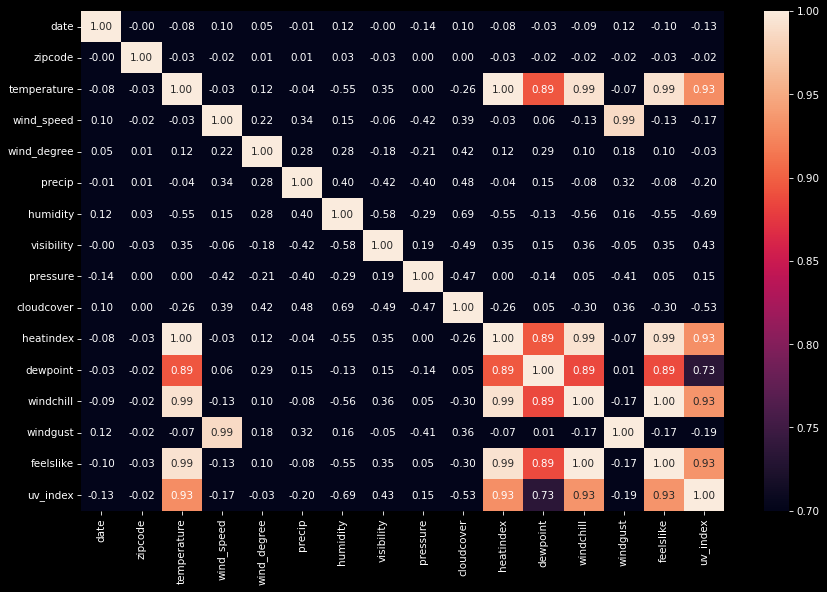


Oberservations:
There are 5 strongly correlated variables to temperature. As well wind_speed to windgust.



In [44]:
# heatmap
plt.figure(figsize=(12,8), dpi=75)
sns.heatmap(num_cols_corr, annot=True, fmt='.2f', vmin=0.7)
plt.tight_layout()
plt.show()

print('''
Oberservations:
There are 5 strongly correlated variables to temperature. As well wind_speed to windgust.
''')

In [45]:
# getting correlated column names of all variables with a correlation over 70 %. 
# adding wind_gust which is highly correlated to wind_speed
corr_cols_to_del = num_cols_corr['temperature'][num_cols_corr['temperature'] > 0.7].index.tolist() + ['windgust']

# removing temperature out of the list, since we don't want to delete it.
corr_cols_to_del.pop(0)

# deleting correlated cols from numeric intermediate dataframe
num_cols_agg = num_cols_agg.drop(columns=corr_cols_to_del)
num_cols_agg

,date,zipcode,temperature,wind_speed,wind_degree,precip,humidity,visibility,pressure,cloudcover
0,2025-01-01,41812,7.0,39.2,226.8,0.1,67.8,9.5,1013.7,73.2
1,2025-01-01,41836,7.0,39.9,223.6,0.1,70.1,9.7,1013.6,68.5
2,2025-01-01,41849,7.0,39.9,223.6,0.1,70.1,9.7,1013.6,68.5
3,2025-01-01,52062,6.5,40.9,223.4,0.1,67.7,9.8,1014.1,55.5
4,2025-01-01,52064,6.5,40.9,223.4,0.1,67.7,9.8,1014.1,55.5
...,...,...,...,...,...,...,...,...,...,...
17455,2026-04-30,52499,10.5,24.0,102.1,0.0,46.3,10.0,1026.9,0.4
17456,2026-04-30,52511,10.5,24.0,102.1,0.0,46.3,10.0,1026.9,0.4
17457,2026-04-30,52525,11.5,23.6,103.5,0.0,43.1,10.0,1027.3,0.2
17458,2026-04-30,52531,10.5,24.0,102.1,0.0,46.3,10.0,1026.9,0.4


## __Investigating correlation of categorical variables__

In [46]:
## weather_code and weather_description seem to be suspiciously close together, let's check

# contingency table
ct = pd.crosstab(cat_cols_agg.weather_description, cat_cols_agg.weather_code)
#print(ct)

chi2, p, dof, exp = chi2_contingency(ct)

n = ct.sum().sum()

rows, cols = ct.shape

cramers_V = np.sqrt(chi2 / (n * (min(rows, cols) - 1 )))

print('Results:')
print('Chi2:\t\t', np.round(chi2, 4))
print('p-value:\t', p)
print('Cramer´s V:\t', np.round(cramers_V, 4))
print()
print(f'''
Interpretation:
The chi2 statistic is very high -> {chi2:.4f},
The p-value {p} shows a significant connection, it's not accidently chosen.
The Cramer´s V with a value of {cramers_V} proves obviuosly a correlation between 
weather_code and weather_description.

Conclusion:
Since some values are twice in weather_description and string values like these 
have a moderate chance to be mistyped or ambigiuos, we remove weather_description.
''')


Results:
Chi2:		 260525.4518
p-value:	 0.0
Cramer´s V:	 0.8637


Interpretation:
The chi2 statistic is very high -> 260525.4518,
The p-value 0.0 shows a significant connection, it's not accidently chosen.
The Cramer´s V with a value of 0.8637498029894598 proves obviuosly a correlation between 
weather_code and weather_description.

Conclusion:
Since some values are twice in weather_description and string values like these 
have a moderate chance to be mistyped or ambigiuos, we remove weather_description.



In [47]:
# removing weather_description
cat_cols_agg = cat_cols_agg.drop('weather_description', axis=1)

In [48]:
# bringing weather num_cols and weatehr cat_cols back together
weather_processed = cat_cols_agg.merge(num_cols_agg, on=['date', 'zipcode'], how='inner')

## __Merging weather with sales_stores_holidays__

In [49]:
# merging weather with rest to final df
sales_stores_holidays_weather = sales_stores_holidays.merge(weather_processed, on=['date', 'zipcode'], how='left')

In [50]:
# check for dupes
print('Duplicates after merging:', sales_stores_holidays_weather.duplicated(subset=['store_id', 'item_id', 'date']).sum())

Duplicates after merging: 0


## __Save combined dataframe__

In [51]:
# change all categorical columns to dtype "category"

# select dtype object and str
to_cat_cols = sales_stores_holidays_weather.select_dtypes(include=['object', 'str']).columns.tolist()
to_cat_cols += ['store_id', 'weather_code' ] # dtype int

# transform categorical cols
sales_stores_holidays_weather[to_cat_cols] = sales_stores_holidays_weather[to_cat_cols].astype('category')

# transform float64 to float32 for less memory usage
to_float32_cols = sales_stores_holidays_weather.select_dtypes(['float64']).columns
sales_stores_holidays_weather[to_float32_cols] = sales_stores_holidays_weather[to_float32_cols].astype('float32')

# check dtpyes and memory usage
print('Info after dtype transformations:')
print(sales_stores_holidays_weather.info())

Info after dtype transformations:
<class 'pandas.DataFrame'>
RangeIndex: 35413245 entries, 0 to 35413244
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   store_id       category      
 1   item_id        category      
 2   date           datetime64[ns]
 3   category_name  category      
 4   sold_quantity  float32       
 5   price          float32       
 6   revenue        float32       
 7   zipcode        category      
 8   holiday_name   category      
 9   holiday_type   category      
 10  wind_dir       category      
 11  weather_code   category      
 12  temperature    float32       
 13  wind_speed     float32       
 14  wind_degree    float32       
 15  precip         float32       
 16  humidity       float32       
 17  visibility     float32       
 18  pressure       float32       
 19  cloudcover     float32       
dtypes: category(8), datetime64[ns](1), float32(11)
memory usage: 2.0 GB
None


In [52]:
# save combined dataframe to disc
sales_stores_holidays_weather.to_parquet('../data/processed/01_df_combined.parquet', index=False)